In [ ]:
# Write a program to modify the intensity/value of a selected pixel and save the modified image.

In [8]:
from PIL import Image
from IPython.display import Image as DisplayImage
import os

def modify_pixel_value(image_path, x, y, new_color):
    """
    Modifies the pixel value at a user-provided (x, y) coordinate
    and saves the modified image.

    Args:
        image_path (str): The path to the input image file.
        x (int): The x-coordinate of the pixel.
        y (int): The y-coordinate of the pixel.
        new_color (tuple): The new RGB color tuple (e.g., (255, 0, 0) for red).

    Returns:
        str: The path to the modified image file, or None if an error occurred.
    """
    try:
        with Image.open(image_path) as img:
            width, height = img.size

            if not (0 <= x < width and 0 <= y < height):
                print(f"Error: Coordinates ({x}, {y}) are out of bounds for an image of size ({width}, {height}).")
                return None

            # Create a copy to modify, as 'img' might be read-only
            modified_img = img.copy()
            modified_img.putpixel((x, y), new_color)

            # Save the modified image with a new name
            file_name, file_extension = image_path.rsplit('.', 1)
            output_path = f"{file_name}_modified_pixel_{x}_{y}.{file_extension}"
            modified_img.save(output_path)
            print(f"Image with modified pixel saved to: {output_path}")
            return output_path
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None



Modifying pixel at (50, 100) to (255, 0, 0) for image: /content/car.1.webp
Image with modified pixel saved to: /content/car.1_modified_pixel_50_100.webp

Original Image:


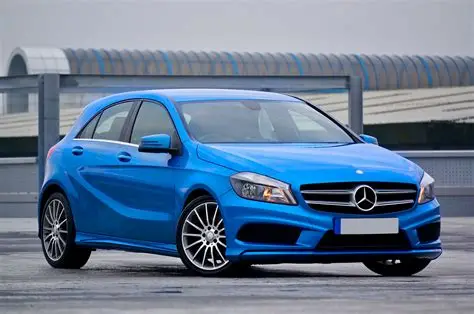


Modified Image:


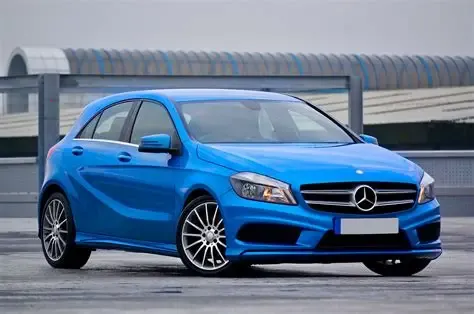

In [11]:
# --- Demo Usage ---

user_image_path = '/content/car.1.webp'

# Coordinates to modify
x_to_modify = 50
y_to_modify = 100

# New color (e.g., bright red)
new_pixel_color = (255, 0, 0)

print(f"\nModifying pixel at ({x_to_modify}, {y_to_modify}) to {new_pixel_color} for image: {user_image_path}")
modified_image_path = modify_pixel_value(user_image_path, x_to_modify, y_to_modify, new_pixel_color)

# Display original and modified images by converting to PNG first
print("\nOriginal Image:")
try:
    with Image.open(user_image_path) as img:
        temp_original_png = "temp_original.png"
        img.save(temp_original_png, "PNG")
        display(DisplayImage(filename=temp_original_png))
finally:
    if os.path.exists(temp_original_png): # Using a try-finally block to ensure file removal
        os.remove(temp_original_png)

if modified_image_path:
    print("\nModified Image:")
    try:
        with Image.open(modified_image_path) as img:
            temp_modified_png = "temp_modified.png"
            img.save(temp_modified_png, "PNG")
            display(DisplayImage(filename=temp_modified_png))
    finally:
        if os.path.exists(temp_modified_png): # Using a try-finally block to ensure file removal
            os.remove(temp_modified_png)